In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import mannwhitneyu, rankdata, fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

from utils.conv_clustering import analyze_clusters, subtype_overview

import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"

In [2]:
# Base directory of the files
base_dir = Path("..").resolve()

# Directories containing the processed files
conv_discovery = base_dir / "2_processed_data" / "3_discovery_convergence"
conv_brand = base_dir / "2_processed_data" / "4_Brand_convergence"
conv_pu = base_dir / "2_processed_data" / "5_Pu_convergence"
conv_dir = base_dir / "2_processed_data" / "6_combined_convergence"
subset_dir = base_dir / "2_processed_data" / "8_T_cell_subsets"
subset_dir.mkdir(exist_ok=True)

# Output directories for the figures and tables
figures_dir = base_dir / "3_figures" / "Figures"
tables_dir = base_dir / "3_figures" / "Tables"
suppl_dir = base_dir / "3_figures" / "Supplementary"

# 1. Cross-cohort convergence

## 1A. Shared clusters volcano plot

In [3]:
# Specify the 36 shared genera
sorted_genera = [
    "Peptoniphilus",
    "Lactobacillus",
    "Desulfovibrio",
    "Porphyromonas",
    "Erysipelotrichaceae",
    "Actinomyces",
    "Dialister",
    "Phascolarctobacterium",
    "Oxalobacter",
    "Paraprevotella",
    "Akkermansia",
    "Parasutterella",
    "Coprococcus",
    "Odoribacter",
    "Coprobacter",
    "Bilophila",
    "Bacteroidales",
    "Sutterella",
    "Prevotella",
    "Streptococcus",
    "Ruminococcaceae",
    "Eubacterium",
    "Escherichia",
    "Clostridium",
    "Pseudoflavonifractor",
    "Anaerostipes",
    "Collinsella",
    "Bifidobacterium",
    "Ruminococcus",
    "Lachnospiraceae",
    "Roseburia",
    "Alistipes",
    "Dorea",
    "Faecalibacterium",
    "Oscillibacter",
    "Parabacteroides",
]

# Extract shared clusters present in all three datasets
results = analyze_clusters(
    genera=sorted_genera,
    cluster_dir=base_dir / "2_processed_data/7_cluster_convergence",
    output_dir=base_dir / "2_processed_data/6_combined_convergence",
    convergence_threshold=2,
    pvalue_threshold=0.05,
    top_percentile=10,
)

# Extract convergent cluster information
grouped_data_list = results["grouped"]
adj_pval_array = results["adjusted_pval"]
summary_frac_data = results["summary_frac"]
all_ranks_data = results["all_ranks"]


# Explore the shared clusters more in detail
shared_clusters = pd.read_csv(
    base_dir / "2_processed_data" / "6_combined_convergence" / "4_red_cluster_TCR.csv"
)

shared_clusters["genus_clus"] = (
    shared_clusters["genus"].astype(str) + "_" + shared_clusters["cluster"].astype(str)
)

shared_clusters["full_vdj"] = (
    shared_clusters["v_call"]
    + "_"
    + shared_clusters["junction_aa"]
    + "_"
    + shared_clusters["j_call"]
)

print(
    "Number of red clusters across all genera:", shared_clusters["genus_clus"].nunique()
)
print("Number of unique TCRs in red clusters:", shared_clusters["full_vdj"].nunique())
print("Number of genera with red clusters:", shared_clusters["genus"].nunique())

Suppl_data_table = shared_clusters[
    [
        "junction_aa",
        "v_call",
        "j_call",
        "patient_id",
        "dataset",
        "cluster",
        "size",
        "motif",
        "genus_clus",
        "genus",
        "pvalue",
        "convergence",
    ]
]

Suppl_data_table["dataset"] = Suppl_data_table["dataset"].replace(
    {"ERC": "Discovery", "Janssen": "Pu et al.", "Twins": "Brand et al."}
)

Suppl_data_table.to_csv(conv_dir / "6_shared_clusters_suppl.csv")

Number of red clusters across all genera: 1268
Number of unique TCRs in red clusters: 26877
Number of genera with red clusters: 21


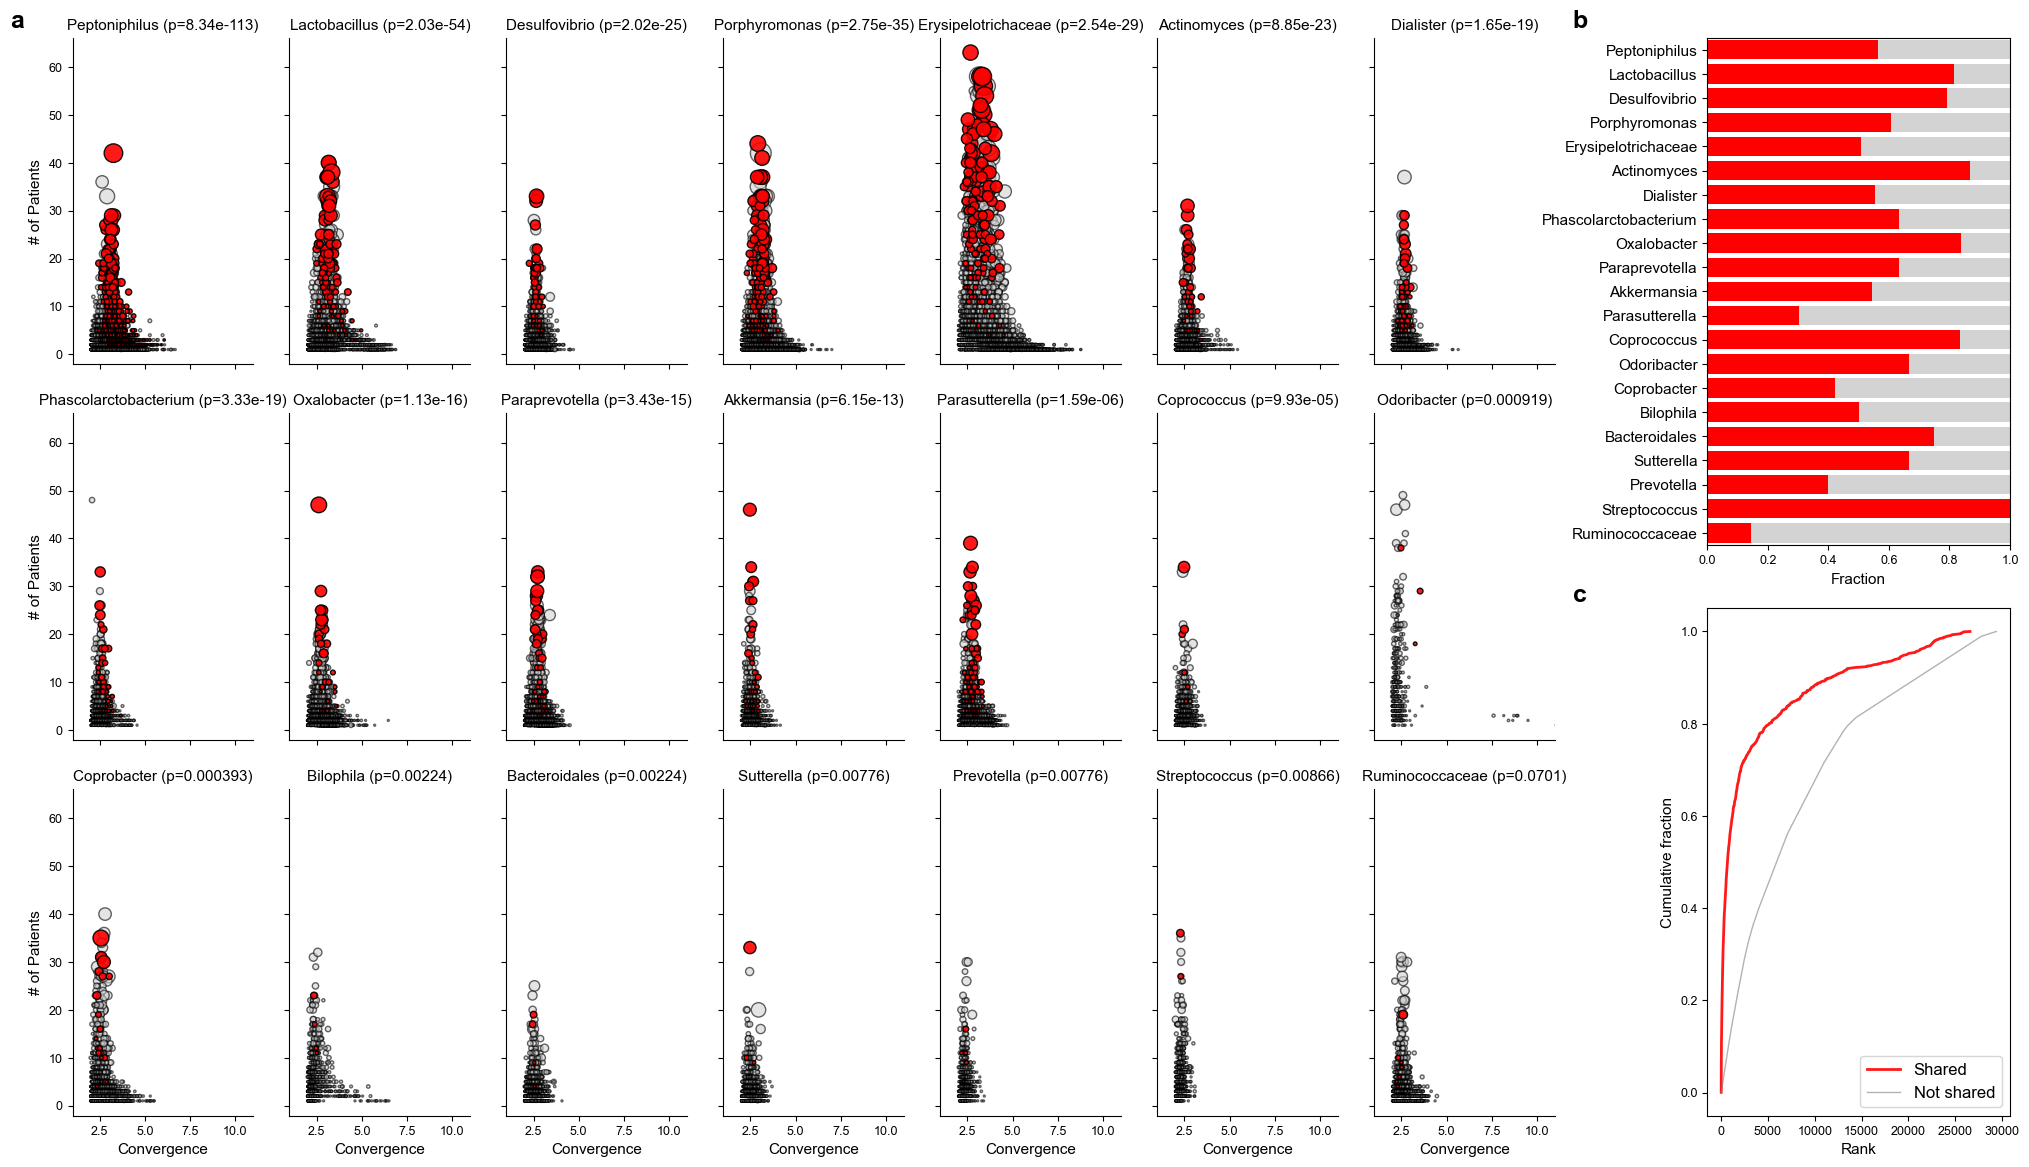

In [4]:
### Global settings #####
figsize = (25, 14)
font_size = 11
marker_alpha = {"red": 0.9, "lightgrey": 0.6}
line_width = {"red": 2, "grey": 1}
scatter_xlim = (1, 11)
scatter_marker_edge = "k"

hspace_main = 0.5
wspace_main = 0.3
hspace_scatter = 0.15
wspace_scatter = 0.2

plt.rcParams.update(
    {
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": font_size,
    }
)

#########################
### Figure generation ###
#########################

fig = plt.figure(figsize=figsize)
gs = fig.add_gridspec(
    6,
    9,
    width_ratios=[1, 1, 1, 1, 1, 1, 1, 0.3, 1.8],
    height_ratios=[1] * 6,
    hspace=hspace_main,
    wspace=wspace_main,
)


# Panel 1: Scatterplots
valid_indices = [
    i
    for i, df_grouped in enumerate(grouped_data_list)
    if df_grouped is not None
    and not df_grouped.empty
    and "red" in df_grouped["color_sharing"].values
]

scatter_gs = gs[:, 0:7].subgridspec(3, 7, hspace=hspace_scatter, wspace=wspace_scatter)
scatter_axes = scatter_gs.subplots(sharex=True, sharey=True).flatten()

for ax, i in zip(scatter_axes, valid_indices):
    df_grouped = grouped_data_list[i]
    for color in ["lightgrey", "red"]:
        subset = df_grouped[df_grouped["color_sharing"] == color]
        if not subset.empty:
            ax.scatter(
                subset["mean_convergence"],
                subset["unique_patients"],
                s=subset["cluster_size"],
                c=color,
                edgecolors=scatter_marker_edge,
                alpha=marker_alpha[color],
            )
    ax.set_xlim(*scatter_xlim)

    pval = adj_pval_array[i]
    title = (
        f"{sorted_genera[i]} (p={pval:.3g})"
        if not np.isnan(pval)
        else f"{sorted_genera[i]} (p=.)"
    )
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in scatter_axes[::7]:
    ax.set_ylabel("# of Patients")

for ax in scatter_axes[-7:]:
    ax.set_xlabel("Convergence")


# Panel 2: Stacked Bar
summary_df = pd.DataFrame(summary_frac_data)
valid_genera = [sorted_genera[i] for i in valid_indices]
summary_df = summary_df[summary_df["Genus"].isin(valid_genera)].copy()
summary_df["FractionTop"] = summary_df["FractionTop"].fillna(0)
summary_df["FractionGrey"] = 1 - summary_df["FractionTop"]

summary_df["Genus"] = pd.Categorical(
    summary_df["Genus"], categories=valid_genera[::-1], ordered=True
)
summary_df.sort_values("Genus", inplace=True)

ax_bar = fig.add_subplot(gs[0:3, 8])
ax_bar.barh(summary_df["Genus"], summary_df["FractionTop"], color="red")
ax_bar.barh(
    summary_df["Genus"],
    summary_df["FractionGrey"],
    left=summary_df["FractionTop"],
    color="lightgrey",
)
ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel("Fraction")
ax_bar.set_ylim(-0.5, len(summary_df) - 0.5)
ax_bar.tick_params(axis="y", labelsize=font_size)


# Panel 3: ECDF
ax_ecdf = fig.add_subplot(gs[3:6, 8])
all_ranks_df = pd.DataFrame(all_ranks_data)
all_ranks_df = all_ranks_df[all_ranks_df["genus"].isin(valid_genera)]

for color, label, cond in [
    ("red", "Shared", all_ranks_df["is_red"]),
    ("grey", "Not shared", ~all_ranks_df["is_red"]),
]:
    ranks = all_ranks_df.loc[cond, "rank"]
    if len(ranks) > 0:
        sorted_ranks = np.sort(ranks)
        y_vals = np.arange(1, len(sorted_ranks) + 1) / len(sorted_ranks)
        ax_ecdf.plot(
            sorted_ranks,
            y_vals,
            color=color,
            label=label,
            linewidth=2 if color == "red" else 1,
            alpha=0.9 if color == "red" else 0.6,
        )

ax_ecdf.set_xlabel("Rank")
ax_ecdf.set_ylabel("Cumulative fraction")
ax_ecdf.legend(loc="lower right", fontsize=12)

# Add panel labels
fig.text(0.1, 0.9, "a", fontsize=18, fontweight="bold", va="top", ha="left")
fig.text(0.725, 0.9, "b", fontsize=18, fontweight="bold", va="top", ha="left")
fig.text(0.725, 0.49, "c", fontsize=18, fontweight="bold", va="top", ha="left")


plt.tight_layout()
plt.savefig(figures_dir / "2A_B_C_convergence_bars_volcano.pdf", bbox_inches="tight")
plt.show()

## 1B. Suppl. figure boxplots shared clusters

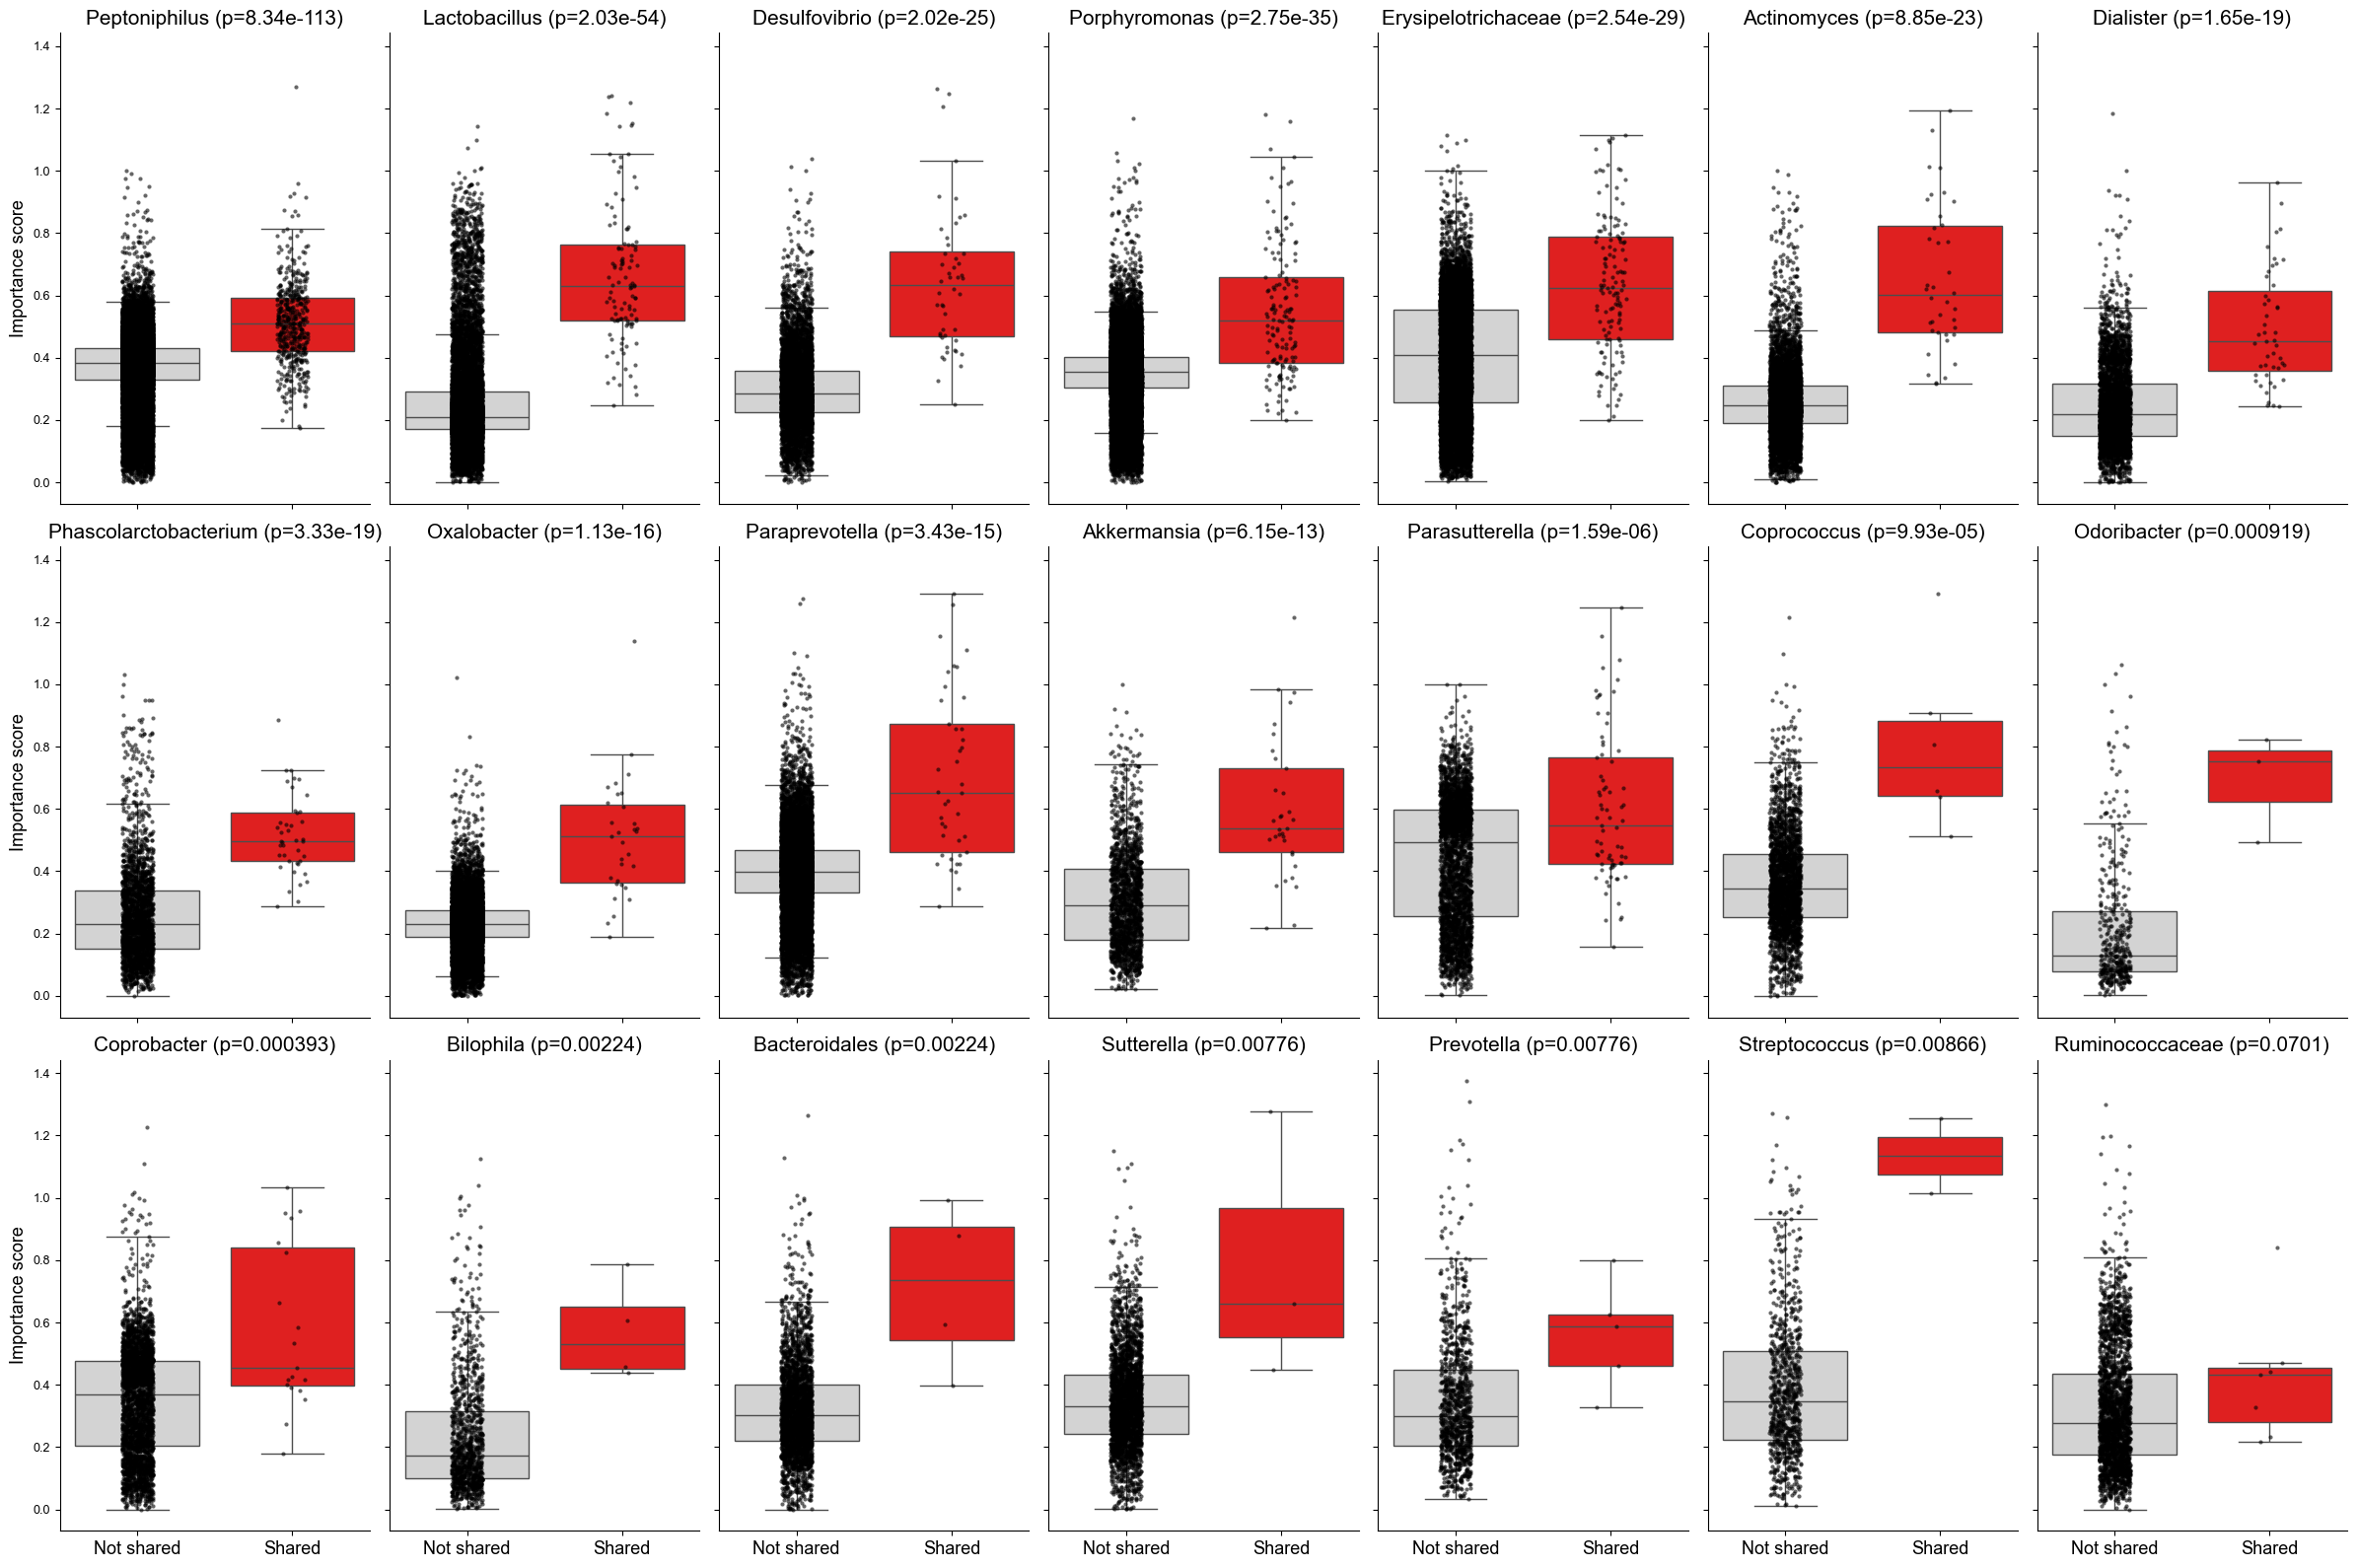

In [5]:
n_valid = len(grouped_data_list)
n_rows, n_cols = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 16), sharex=True, sharey=True)
axes = axes.flatten()

for i, (genus, df_grouped, pval) in enumerate(
    zip(valid_genera, grouped_data_list, adj_pval_array)
):
    ax = axes[i]

    sns.boxplot(
        data=df_grouped,
        x="color_sharing",
        y="topright_score",
        palette={"red": "red", "lightgrey": "lightgrey"},
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=df_grouped,
        x="color_sharing",
        y="topright_score",
        color="black",
        jitter=True,
        size=3,
        alpha=0.6,
        ax=ax,
    )

    ax.set_xticklabels(["Not shared", "Shared"], size=13)
    ax.set_title(
        f"{genus} (p={pval:.3g})" if not np.isnan(pval) else f"{genus} (p=.)", size=15
    )
    ax.set_ylabel("Importance score" if i % n_cols == 0 else "", size=13)
    ax.set_xlabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused axes
for j in range(n_valid, n_rows * n_cols):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.savefig(suppl_dir / "S2_convergence_boxplots.pdf", bbox_inches="tight")
plt.show()

# 2. T cell subtype preference in convergent TCRs

### Discovery cohort

In [6]:
# Original unfiltered data before convergence analysis (=All TCRs used for the convergence analysis)
data_alpha = pd.read_csv(conv_discovery / "TRA_dataframe.csv")
data_beta = pd.read_csv(conv_discovery / "TRB_dataframe.csv")

together = pd.concat([data_alpha, data_beta])
together["erc_cell"] = together["repertoire_id"].str.split(r"[_-]").str[2]
together["group"] = together["chain"] + "_" + together["erc_cell"]


# All TCRs that were found to be significantly convergent
final_conv = pd.read_csv(conv_dir / "0_combined_final_sign_interactions.csv")
final_conv = final_conv[final_conv["dataset"] == "Discovery"]


# Compare the T cell subtypes included in the convergent groups versus at the start
full_tcr_info = pd.merge(
    together,
    final_conv[
        [
            "junction",
            "junction_aa",
            "v_call",
            "j_call",
            "patient_id",
            "statistic",
            "pvalue",
            "convergence",
            "genus",
        ]
    ],
    how="left",
)
full_tcr_info = full_tcr_info[
    [
        "junction",
        "junction_aa",
        "v_call",
        "j_call",
        "patient_id",
        "erc_cell",
        "statistic",
        "pvalue",
        "convergence",
        "genus",
        "group",
    ]
].drop_duplicates()


full_tcr_info["convergent"] = np.where(
    (full_tcr_info["convergence"] > 2) & (full_tcr_info["pvalue"] < 0.05), "Yes", "No"
)

before_df = full_tcr_info.drop_duplicates(
    subset=["junction", "junction_aa", "v_call", "j_call", "patient_id", "erc_cell"]
).drop(columns={"statistic", "pvalue", "convergence", "genus", "convergent"})

keys = ["junction", "junction_aa", "v_call", "j_call", "patient_id", "erc_cell"]
before_hash = before_df[keys].apply(lambda x: hash(tuple(x)), axis=1).to_numpy()

before_df.to_csv(subset_dir / "1_before_disc_data.csv")
full_tcr_info.to_csv(subset_dir / "1_full_info_disc_data.csv")

### Pu et al.

In [7]:
# Original unfiltered data before convergence analysis (=All TCRs used for the convergence analysis)
data_alpha = pd.read_csv(conv_pu / "TRA_dataframe.csv")
data_beta = pd.read_csv(conv_pu / "TRB_dataframe.csv")
together = pd.concat([data_alpha, data_beta])

# All TCRs that were found to be significantly convergent
final_conv = pd.read_csv(conv_dir / "0_combined_final_sign_interactions.csv")
final_conv = final_conv[final_conv["dataset"] == "Pu"]

# Compare the T cell subtypes included in the convergent groups versus at the start
full_tcr_info = pd.merge(
    together,
    final_conv[
        [
            "junction",
            "junction_aa",
            "v_call",
            "j_call",
            "patient_id",
            "statistic",
            "pvalue",
            "convergence",
            "genus",
        ]
    ],
    how="left",
)
full_tcr_info = full_tcr_info[
    [
        "junction",
        "junction_aa",
        "v_call",
        "j_call",
        "patient_id",
        "repertoire_id",
        "cell_type",
        "statistic",
        "pvalue",
        "convergence",
        "genus",
    ]
].drop_duplicates()


full_tcr_info["convergent"] = np.where(
    (full_tcr_info["convergence"] > 2) & (full_tcr_info["pvalue"] <= 0.05), "Yes", "No"
)

before_df = full_tcr_info.drop_duplicates(
    subset=["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]
).drop(columns={"statistic", "pvalue", "convergence", "genus", "convergent"})

keys = ["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]
before_hash = before_df[keys].apply(lambda x: hash(tuple(x)), axis=1).to_numpy()

before_df.to_csv(subset_dir / "2_before_Pu_data.csv")
full_tcr_info.to_csv(subset_dir / "2_full_info_Pu_data.csv")

### Brand et al.

In [8]:
# Original unfiltered data before convergence analysis (=All TCRs used for the convergence analysis)
data = pd.read_csv(
    base_dir / "2_processed_data" / "1_Brand_data" / "0_parsed_full_IBD_data.csv"
)

data["Concordancy"] = data["Concordancy"].fillna("Healthy")
data.loc[data["Concordancy"] == "Healthy", "Diagnosis"] = "Healthy"

twin_samples = [
    "TWIN0001",
    "TWIN0002",
    "TWIN0011",
    "TWIN0012",
    "TWIN0015",
    "TWIN0016",
    "TWIN0041",
    "TWIN0042",
    "TWIN0045",
    "TWIN0046",
    "TWIN0081",
    "TWIN0082",
    "TWIN0099",
    "TWIN0100",
    "TWIN0101",
    "TWIN0102",
]

data = data[data["patient_id"].isin(twin_samples)]
together = data[
    ["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]
]


# All TCRs that were found to be significantly convergent
final_conv = pd.read_csv(conv_dir / "0_combined_final_sign_interactions.csv")
final_conv = final_conv[final_conv["dataset"] == "Brand"]


# Compare the T cell subtypes included in the convergent groups versus at the start
full_tcr_info = pd.merge(
    together,
    final_conv[
        [
            "junction",
            "junction_aa",
            "v_call",
            "j_call",
            "patient_id",
            "statistic",
            "pvalue",
            "convergence",
            "genus",
        ]
    ],
    how="left",
)
full_tcr_info = full_tcr_info[
    [
        "junction",
        "junction_aa",
        "v_call",
        "j_call",
        "patient_id",
        "cell_type",
        "statistic",
        "pvalue",
        "convergence",
        "genus",
    ]
].drop_duplicates()

full_tcr_info["convergent"] = np.where(
    (full_tcr_info["convergence"] > 2) & (full_tcr_info["pvalue"] <= 0.05), "Yes", "No"
)

before_df = full_tcr_info.drop_duplicates(
    subset=["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]
).drop(columns={"statistic", "pvalue", "convergence", "genus", "convergent"})

keys = ["junction", "junction_aa", "v_call", "j_call", "patient_id", "cell_type"]
before_hash = before_df[keys].apply(lambda x: hash(tuple(x)), axis=1).to_numpy()


before_df.to_csv(subset_dir / "3_before_Brand_data.csv")
full_tcr_info.to_csv(subset_dir / "3_full_info_Brand_data.csv")

### Combine them

In [9]:
# Discovery data
full_tcr_disc = pd.read_csv(
    subset_dir / "1_full_info_disc_data.csv", index_col=0
).rename(columns={"erc_cell": "cell_type"})
before_df_disc = pd.read_csv(subset_dir / "1_before_disc_data.csv", index_col=0).rename(
    columns={"erc_cell": "cell_type"}
)

# CRC data
full_tcr_pu = pd.read_csv(subset_dir / "2_full_info_Pu_data.csv", index_col=0)
before_df_pu = pd.read_csv(subset_dir / "2_before_Pu_data.csv", index_col=0)

# IBD data
full_tcr_brand = pd.read_csv(subset_dir / "3_full_info_Brand_data.csv", index_col=0)
before_df_brand = pd.read_csv(subset_dir / "3_before_Brand_data.csv", index_col=0)

In [10]:
# 21 genera with shared clusters identified
sorted_genera = [
    "Peptoniphilus",
    "Lactobacillus",
    "Desulfovibrio",
    "Porphyromonas",
    "Erysipelotrichaceae",
    "Actinomyces",
    "Dialister",
    "Phascolarctobacterium",
    "Oxalobacter",
    "Paraprevotella",
    "Akkermansia",
    "Parasutterella",
    "Coprococcus",
    "Odoribacter",
    "Coprobacter",
    "Bilophila",
    "Bacteroidales",
    "Sutterella",
    "Prevotella",
    "Streptococcus",
    "Ruminococcaceae",
]

# Datasets used in the T cell subset comparison
datasets = [
    ("Dataset A", full_tcr_disc, before_df_disc),
    ("Dataset B", full_tcr_pu, before_df_pu),
    ("Dataset C", full_tcr_brand, before_df_brand),
]

# Compare cell type distributions in starting data and convergent TCRs
per_ds = [
    subtype_overview(fi, bf, sorted_genera, name, group_col="cell_type")
    for (name, fi, bf) in datasets
]
res_df_all = pd.concat(per_ds, ignore_index=True)


heatmap = res_df_all.pivot_table(
    index=["dataset", "cell_type"], columns="genus", values="Log2FC", aggfunc="mean"
)

heatmap = heatmap.reindex(columns=sorted_genera)
heatmap = heatmap.fillna(0)

row_order = []
for name, _, _ in datasets:
    cts = sorted(res_df_all.loc[res_df_all["dataset"] == name, "cell_type"].unique())
    row_order.extend([(name, ct) for ct in cts])

row_order = [idx for idx in row_order if idx in heatmap.index]
heatmap = heatmap.loc[row_order]
heatmap_disp = heatmap.copy()
heatmap_disp.index = [f"   | {ct}" for d, ct in heatmap.index]

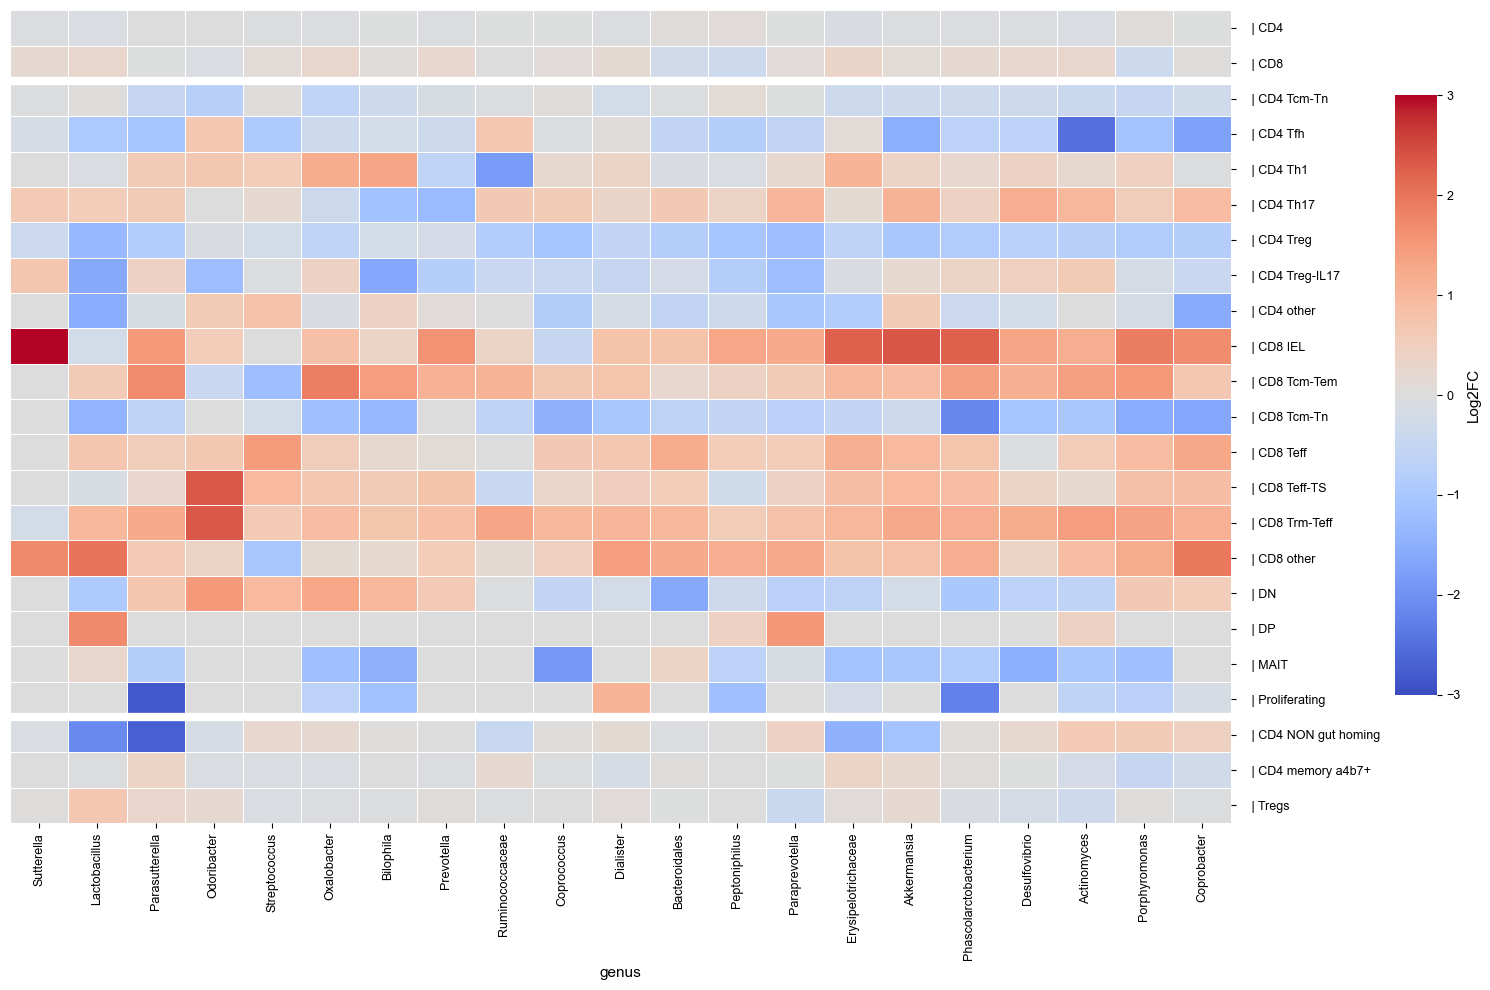

In [11]:
#########################
### Figure generation ###
#########################

g = sns.clustermap(
    heatmap_disp,
    cmap="coolwarm",
    center=0,
    vmin=-3,
    vmax=3,
    linewidths=0.5,
    row_cluster=False,
    col_cluster=True,
    figsize=(14, 10),
    dendrogram_ratio=(0.000001, 0.0000001),
    cbar_kws={"label": "Log2FC"},
    cbar_pos=(1.0, 0.3, 0.03, 0.6),
    xticklabels=True,
    yticklabels=True,
)


plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="center")

row_counts = []
for name, _, _ in datasets:
    count = sum(heatmap.index.get_level_values(0) == name)
    if count > 0:
        row_counts.append(count)

boundaries = np.cumsum(row_counts)[:-1] if row_counts else []
for y in boundaries:
    g.ax_heatmap.hlines(y, *g.ax_heatmap.get_xlim(), colors="white", linewidth=6)

plt.title("", pad=20)
plt.savefig(suppl_dir / "S3_T_cell_subtype_heatmap_21.pdf", bbox_inches="tight")
plt.show()